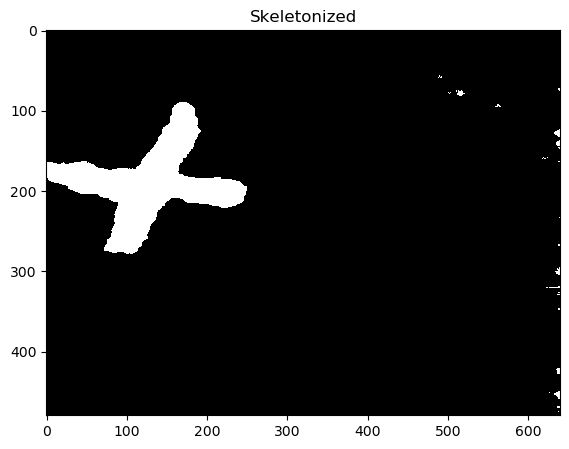

Mask dtype: uint8
Mask shape: (480, 640)
Unique values in mask: [  0 255]


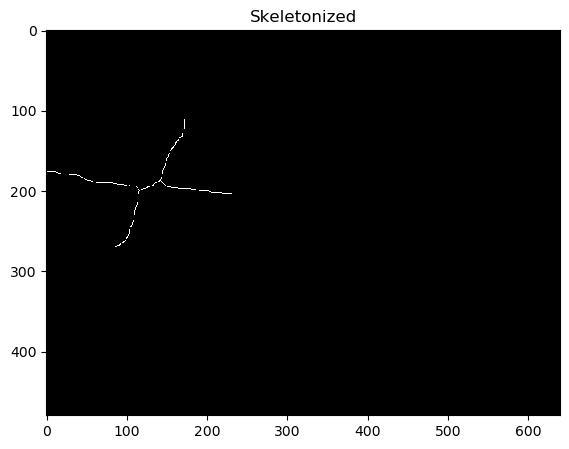

Skeleton unique values: [  0 255]


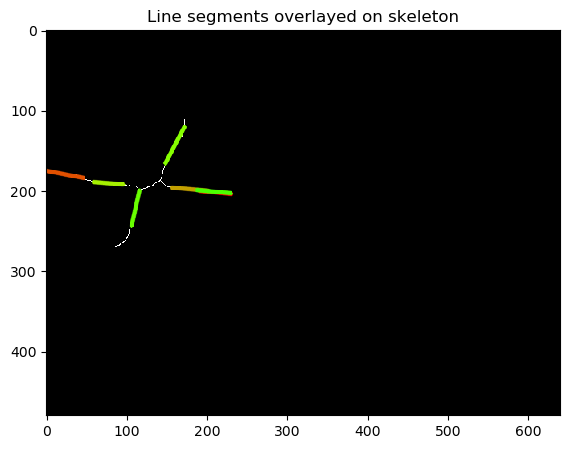

lines1:
[[[190 200 231 204]]

 [[  0 175  47 184]]

 [[156 196 202 200]]

 [[ 58 189  96 192]]

 [[148 166 172 120]]

 [[106 244 116 199]]

 [[187 199 230 203]]]
Line 0   Angle 5.572197803963795,     Midpoint(210.5, 202.0)
Line 1   Angle 10.840305454330565,     Midpoint(23.5, 179.5)
Line 2   Angle 4.969740728110304,     Midpoint(179.0, 198.0)
Line 3   Angle 4.513988458001262,     Midpoint(77.0, 190.5)
Line 4   Angle 117.5528115767178,     Midpoint(160.0, 143.0)
Line 5   Angle 102.52880770915151,     Midpoint(111.0, 221.5)
Line 6   Angle 5.31454566994475,     Midpoint(208.5, 201.0)


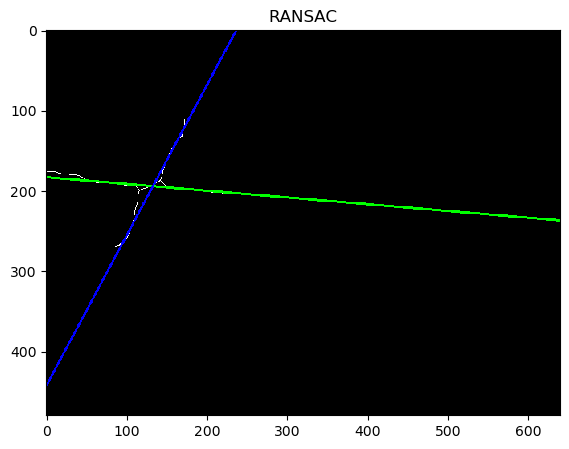

Skeleton unique values: [  0 255]


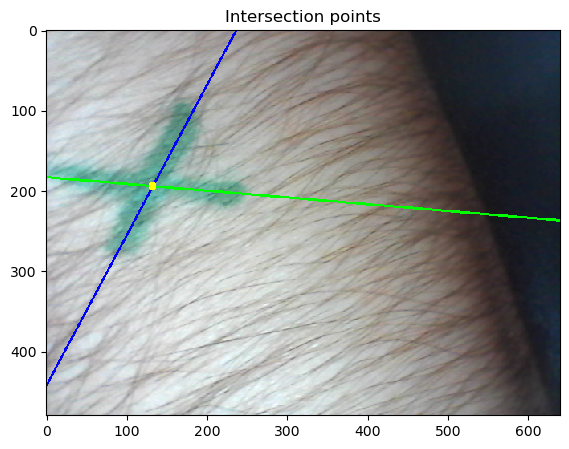

INTERSECTION POINT IN IMAGE1 LOCATED AT: X= 132  Y= 194


In [12]:
#-------I made this because I was having trouble with DetectAndFindXPoint.py
#That code wasnt detecting segments simply because I have a mistake in skeleton_find_line_segments
#which was preventing parameters from being recognized correctly.
#However, there is still something weird. The skeletonization either works differently or is displayed differently in the jupyter notebook.
#This could be due to weird plt display issues, or maybe a different version of ximproc thinning.


#Steps used
#Mask
#Morphological opening
#Skeletonization
#HoughLinesP
#Find the angles of the lines
#Group lines using Kmeans clustering according to their angles
#Use RANSAC on the endpoints of lines in the same group to get slope and intercept for each group
#Find the intersection point

import cv2
import numpy as np
from skimage.exposure import match_histograms
from sklearn.cluster import KMeans
from sklearn.linear_model import RANSACRegressor
import matplotlib.pyplot as plt
import os
import sys
import math
src_file_path = '/home/vboxuser/VisionForStewart/XDetection/'
TRIANGULATION_DIR = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'Triangulation'))
sys.path.append(TRIANGULATION_DIR)
CIRCLE_DIR = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'CircleDetection'))
sys.path.append(CIRCLE_DIR)
DETECT_AND_FIND_CONTOUR = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'DetectAndFindContour'))
sys.path.append(DETECT_AND_FIND_CONTOUR)

ALLSTEPS_LIB = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'DetectAndFindContour'))
sys.path.append(ALLSTEPS_LIB)
import triangulate_pts
import contour_det_lib
import AllSteps

def sketon_find_line_segments(skeletonImg, thresholdAccumVotesNeeded = 30, minLineLength = 10, maxLineGap = 20):
    #Creating an image so that I can see the line segments
    linesOnSkeleton = skeletonImg.copy()
    linesOnSkeleton = cv2.cvtColor(linesOnSkeleton, cv2.COLOR_GRAY2BGR)
    #lines = cv2.HoughLinesP(skeletonImg, 1, np.pi / 180, thresholdAccumVotesNeeded, minLineLength, maxLineGap)
    lines = cv2.HoughLinesP(skeletonImg, 1, np.pi / 180, threshold=thresholdAccumVotesNeeded, minLineLength=minLineLength, maxLineGap=maxLineGap)
    if lines is not None:
        for i in range(0, len(lines)):
            l = lines[i][0]
            cv2.line(linesOnSkeleton, (l[0], l[1]), (l[2], l[3]), (0,80*i,255-30*i), 3, cv2.LINE_AA)
    else:
        print("WARNING: NO LINES FOUND ON SKELETON")
    return lines, linesOnSkeleton


def line_to_angle_and_midpoint(line):
    #This function gets the angel and the midpoint of the given line segment
    x1, y1, x2, y2 = line
    angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
    midpoint = ((x1 + x2) / 2, (y1 + y2) / 2)
    return angle % 180, midpoint  # Use angle mod 180 to treat parallel lines the same


def get_endpoints_of_lines(line_group):
    points = []
    for l in line_group:
        x1,y1,x2,y2 = l[0] #Get endpoints of that line
        points.append([x1, y1])
        points.append([x2, y2])
    return np.array(points)


def group_line_segments(lines, num_clusters=2, n_num_init=10):
    if(len(lines) < 2):
        print("Less than 2 lines detected in image. Cannot proceed")
        return
    angles = []
    for i in range(len(lines)):
        angle, midpoint = line_to_angle_and_midpoint(lines[i][0])
        print(f"Line {i}   Angle {angle},     Midpoint{midpoint}")
        angles.append([angle]) #Need brackets or reshape into column for kmeans

    #print(angles)
    kmeans = KMeans(n_clusters = num_clusters, n_init=n_num_init).fit(angles)
    labels = kmeans.labels_
    #print(labels)
    lineGroup1 = [lines[i] for i in range(len(lines)) if labels[i] == 0]
    lineGroup2 = [lines[i] for i in range(len(lines)) if labels[i] == 1]

    endPtsGrp1 = get_endpoints_of_lines(lineGroup1)
    endPtsGrp2 = get_endpoints_of_lines(lineGroup2)
    return endPtsGrp1, endPtsGrp2


#RANSAC to get a line from a list of points
def ransac_fit_line(points):
    X = points[:, 0].reshape(-1, 1)  # x values as 2D array
    y = points[:, 1]                # y values as 1D array
    ransac = RANSACRegressor(min_samples=2, residual_threshold=2.0)
    ransac.fit(X, y)
    slope = ransac.estimator_.coef_[0]
    intercept = ransac.estimator_.intercept_
    return slope, intercept


def draw_line_from_slope(img, m, b, color):
    h, w = img.shape[:2]
    pt1 = (0, int(b))
    pt2 = (w, int(m * w + b))
    cv2.line(img, pt1, pt2, color, 2)

def line_intersection(m1, b1, m2, b2):
    if m1 == m2:
        return None  # Parallel lines
    x = (b2 - b1) / (m1 - m2)
    y = m1 * x + b1
    return int(x), int(y)



def main():
    OUTPUT_DIRECTORY = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'stereo_calibration_params', 'stereo_calibration_data.pkl'))
    cameraMatrix1, distCoeffs1, cameraMatrix2, distCoeffs2, R_Mat, T_Vec = triangulate_pts.read_params(OUTPUT_DIRECTORY)
    #Assuming I had two images
    img1 = cv2.imread("xOnSkin.png")
    #img2 = cv2.imread("stereo_images/90mmR.png")

    '''
    #Step 0: Rectify and undistort
    width = img1.shape[1]
    height = img1.shape[0]
    map1x, map1y, map2x, map2y, P1, P2 = triangulate_pts.get_undistort_rectification_maps(cameraMatrix1, distCoeffs1, cameraMatrix2, distCoeffs2, R_Mat, T_Vec, (width, height))
    LUndist, RUndist = triangulate_pts.undistort_images(img1, img2, map1x, map1y, map2x, map2y)
    AllSteps.display_SideBySide(LUndist, RUndist, "Undistorted images")
    img1 = LUndist
    img2 = RUndist
    

    #Step 1: Perform histogram matching
    #img2 = histogram_match(img1, img2)
    img2 = AllSteps.color_transfer(img1, img2)
    AllSteps.display_SideBySide(img1, img2, "Post histogram matching")
    '''

    #Step 2: Develop the mask
    low_hsv_val = np.array([40, 30, 0])
    high_hsv_val = np.array([99, 255, 255])
    mask1 = AllSteps.find_hsv_mask(img1, low_hsv_val, high_hsv_val, blur=True)
    masked_img1 = AllSteps.apply_hsv_mask(img1, mask1)
    
    plt.figure(figsize=(15,5))
    plt.imshow(cv2.cvtColor(mask1, cv2.COLOR_BGR2RGB))
    plt.title("Skeletonized")
    plt.show()
    print("Mask dtype:", mask1.dtype)
    print("Mask shape:", mask1.shape)
    print("Unique values in mask:", np.unique(mask1))

    #Step 3: Clean the mask
    clean1 = cv2.morphologyEx(mask1, cv2.MORPH_OPEN, np.ones((10, 10), np.uint8))

    #Step 4: Skeletonize mask
    skeleton1 = cv2.ximgproc.thinning(clean1)
    plt.figure(figsize=(15,5))
    plt.imshow(cv2.cvtColor(skeleton1, cv2.COLOR_BGR2RGB))
    plt.title("Skeletonized")
    plt.show()
    print("Skeleton unique values:", np.unique(skeleton1))
    cv2.imwrite("debug_clean.png", clean1)
    cv2.imwrite("debug_skeleton.png", skeleton1)
    
    #Step 5: Find line segments in the skeleton
    lines1, lineSegsOnSkeletonImage1 = sketon_find_line_segments(skeleton1)
    #cv2.imshow("Line segments overlayed on skeleton", lineSegsOnSkeletonImage1)
    plt.figure(figsize=(15,5))
    plt.imshow(cv2.cvtColor(lineSegsOnSkeletonImage1, cv2.COLOR_BGR2RGB))
    plt.title("Line segments overlayed on skeleton")
    plt.show()
    #print("Skeleton unique values:", np.unique(skeleton1))
    #cv2.imwrite("debug_clean.png", clean1)
    #cv2.imwrite("debug_skeleton.png", skeleton1)
    print("lines1:")
    print(lines1)
    

    #Step 6: Cluster line segments
    img1EndPtsGrp1, img1EndPtsGrp2 = group_line_segments(lines1)

    #Step 7: Use RANSAC to find two lines
    img1m1, img1b1 = ransac_fit_line(img1EndPtsGrp1)
    img1m2, img1b2 = ransac_fit_line(img1EndPtsGrp2)
    img1FittedLines = skeleton1.copy()
    img1FittedLines = cv2.cvtColor(img1FittedLines, cv2.COLOR_GRAY2BGR)
    draw_line_from_slope(img1FittedLines, img1m1, img1b1, (0, 255, 0))
    draw_line_from_slope(img1FittedLines, img1m2, img1b2, (255, 0, 0))
    #cv2.imshow("RANSAC fitted lines on the skeleton", img1FittedLines)
    plt.figure(figsize=(15,5))
    plt.imshow(cv2.cvtColor(img1FittedLines, cv2.COLOR_BGR2RGB))
    plt.title("RANSAC")
    plt.show()
    print("Skeleton unique values:", np.unique(skeleton1))
    cv2.imwrite("debug_clean.png", clean1)
    cv2.imwrite("debug_skeleton.png", skeleton1)

    #Step 8: Find the intersection point
    fittedLinesOnOriginalImg1 = img1.copy()
    draw_line_from_slope(fittedLinesOnOriginalImg1, img1m1, img1b1, (0, 255, 0))
    draw_line_from_slope(fittedLinesOnOriginalImg1, img1m2, img1b2, (255, 0, 0))
    img1IntersectX, img1IntersectY = line_intersection(img1m1, img1b1, img1m2, img1b2)
    cv2.circle(fittedLinesOnOriginalImg1, (img1IntersectX, img1IntersectY), 5, (0, 255, 255), -1)
    #cv2.imshow("Intersection points on original rect and undist image", fittedLinesOnOriginalImg1)
    plt.figure(figsize=(15,5))
    plt.imshow(cv2.cvtColor(fittedLinesOnOriginalImg1, cv2.COLOR_BGR2RGB))
    plt.title("Intersection points")
    plt.show()
    print("INTERSECTION POINT IN IMAGE1 LOCATED AT: X=", img1IntersectX, " Y=", img1IntersectY)

if __name__ == "__main__":
    main()

